In [1]:
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm


In [2]:
train_df = pd.read_csv("/home/dxk/Data/Repos/Final_Data_Viz/data/main/raw/sales.csv")
train_df.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


In [4]:
forecast_df = pd.read_csv("/home/dxk/Data/Repos/Final_Data_Viz/data/main/raw/sample_submission.csv")
forecast_df.head()

,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


In [5]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     548 non-null    object 
 1   Revenue  548 non-null    float64
 2   COGS     548 non-null    float64
dtypes: float64(2), object(1)
memory usage: 13.0+ KB


In [6]:
import logging
import warnings

import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from pmdarima import auto_arima

    HAS_PMDARIMA = True
except Exception:
    HAS_PMDARIMA = False


logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("arima_pipeline")

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def prepare_series(df, date_col, value_col):
    dfx = df[[date_col, value_col]].copy()
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")
    dfx = dfx.dropna(subset=[date_col]).sort_values(date_col)
    dfx[value_col] = pd.to_numeric(dfx[value_col], errors="coerce")
    dfx[value_col] = dfx[value_col].replace([np.inf, -np.inf], np.nan)

    dfx = dfx.set_index(date_col)
    freq = pd.infer_freq(dfx.index)
    if freq is None:
        freq = "D"

    dfx = dfx.asfreq(freq)
    if dfx[value_col].isna().any():
        dfx[value_col] = dfx[value_col].interpolate(method="time").ffill().bfill()

    if dfx[value_col].isna().any() or not np.isfinite(dfx[value_col]).all():
        raise ValueError(f"{value_col} contains invalid values after cleaning.")

    return dfx[value_col], freq


def adf_find_d(series, max_d=3, alpha=0.05):
    d = 0
    current = series.copy()
    last_p = 1.0

    while d <= max_d:
        try:
            p_value = adfuller(current.dropna(), autolag="AIC")[1]
        except Exception:
            p_value = 1.0

        last_p = p_value
        if p_value < alpha:
            return d, p_value

        d += 1
        current = current.diff().dropna()

    return max_d, last_p


def infer_seasonal_period(freq):
    if freq is None:
        return None
    if freq.startswith("D") or freq == "B":
        return 7
    if freq.startswith("W"):
        return 52
    if freq in ("M", "MS"):
        return 12
    if freq in ("Q", "QS"):
        return 4
    if freq == "H":
        return 24
    return None


def fit_arima(series, d, seasonal_m=None, max_p=3, max_q=3):
    if HAS_PMDARIMA:
        seasonal = seasonal_m is not None and len(series) >= 2 * seasonal_m
        model = auto_arima(
            series,
            d=d,
            max_d=d,
            seasonal=seasonal,
            m=seasonal_m if seasonal else 1,
            max_p=max_p,
            max_q=max_q,
            max_P=1,
            max_Q=1,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            information_criterion="aic",
        )
        return {
            "type": "pmdarima",
            "model": model,
            "order": model.order,
            "seasonal_order": getattr(model, "seasonal_order", None),
        }

    best_aic = np.inf
    best_res = None
    best_order = None

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                res = SARIMAX(
                    series,
                    order=(p, d, q),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = (p, d, q)
            except Exception:
                continue

    if best_res is None:
        best_order = (1, d, 0)
        best_res = SARIMAX(
            series,
            order=best_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

    return {
        "type": "statsmodels",
        "model": best_res,
        "order": best_order,
        "seasonal_order": None,
    }


def model_residuals(fit):
    if fit["type"] == "pmdarima":
        return fit["model"].resid()
    return fit["model"].resid


def model_forecast(fit, steps):
    if fit["type"] == "pmdarima":
        preds = fit["model"].predict(n_periods=steps)
    else:
        preds = fit["model"].get_forecast(steps).predicted_mean.values
    return np.asarray(preds, dtype=float)


def is_valid_forecast(values):
    values = np.asarray(values)
    return values.size > 0 and np.isfinite(values).all()


def ljung_box_report(residuals, label):
    residuals = pd.Series(residuals).dropna()
    lag = max(1, min(10, len(residuals) // 5))
    lb = acorr_ljungbox(residuals, lags=[lag], return_df=True)
    p_value = lb["lb_pvalue"].iloc[0]
    if p_value < 0.05:
        logger.info("%s Ljung-Box p=%.4f -> residuals autocorrelated", label, p_value)
    else:
        logger.info("%s Ljung-Box p=%.4f -> residuals not autocorrelated", label, p_value)
    return p_value


def safe_fit_forecast(series, d, steps, seasonal_m, label):
    fit = fit_arima(series, d, seasonal_m=seasonal_m)
    preds = model_forecast(fit, steps)
    if is_valid_forecast(preds):
        return fit, preds

    logger.warning("%s forecast invalid; retrying without seasonality", label)
    fit = fit_arima(series, d, seasonal_m=None)
    preds = model_forecast(fit, steps)
    if is_valid_forecast(preds):
        return fit, preds

    logger.warning("%s forecast invalid; retrying with SARIMAX(1,%d,0)", label, d)
    try:
        fit = {
            "type": "statsmodels",
            "model": SARIMAX(
                series,
                order=(1, d, 0),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False),
            "order": (1, d, 0),
            "seasonal_order": None,
        }
        preds = model_forecast(fit, steps)
        if is_valid_forecast(preds):
            return fit, preds
    except Exception:
        pass

    logger.warning("%s forecast invalid; using last-value fallback", label)
    last_value = series.iloc[-1]
    preds = np.full(steps, last_value, dtype=float)
    return None, preds


def run_pipeline(train_df, forecast_df):
    required = {"Date", "Revenue", "COGS"}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"Missing columns in train_df: {sorted(list(missing))}")

    if "Date" not in forecast_df.columns:
        raise ValueError("Missing Date column in forecast_df")

    revenue_series, freq = prepare_series(train_df, "Date", "Revenue")
    cogs_series, _ = prepare_series(train_df, "Date", "COGS")

    corr = pd.concat([revenue_series, cogs_series], axis=1).corr().iloc[0, 1]
    logger.info("Revenue-COGS corr: %.3f", corr)

    forecast_work = forecast_df.copy()
    forecast_work["__order__"] = np.arange(len(forecast_work))
    forecast_work["Date"] = pd.to_datetime(forecast_work["Date"], errors="coerce")
    if forecast_work["Date"].isna().any():
        raise ValueError("forecast_df has invalid Date values.")

    forecast_work = forecast_work.sort_values("Date").reset_index(drop=True)
    steps = len(forecast_work)

    seasonal_m = infer_seasonal_period(freq)

    d_rev, p_rev = adf_find_d(revenue_series)
    logger.info("Revenue ADF p=%.4f -> d=%d", p_rev, d_rev)
    fit_rev, pred_rev = safe_fit_forecast(
        revenue_series, d_rev, steps, seasonal_m, label="Revenue"
    )
    if fit_rev is not None:
        logger.info(
            "Revenue order=%s seasonal=%s",
            fit_rev["order"],
            fit_rev["seasonal_order"],
        )
        ljung_box_report(model_residuals(fit_rev), "Revenue")

    d_cogs, p_cogs = adf_find_d(cogs_series)
    logger.info("COGS ADF p=%.4f -> d=%d", p_cogs, d_cogs)
    fit_cogs, pred_cogs = safe_fit_forecast(
        cogs_series, d_cogs, steps, seasonal_m, label="COGS"
    )
    if fit_cogs is not None:
        logger.info(
            "COGS order=%s seasonal=%s",
            fit_cogs["order"],
            fit_cogs["seasonal_order"],
        )
        ljung_box_report(model_residuals(fit_cogs), "COGS")

    forecast_work["Revenue"] = pred_rev
    forecast_work["COGS"] = pred_cogs

    forecast_out = forecast_work.sort_values("__order__")
    forecast_out["Date"] = forecast_out["Date"].dt.strftime("%Y-%m-%d")
    forecast_out = forecast_out[["Date", "Revenue", "COGS"]]

    forecast_out.to_csv("submission_arima.csv", index=False)
    return forecast_out


# forecast_df = run_pipeline(train_df, forecast_df)
# forecast_df.head()

In [7]:
from statsmodels.tsa.api import VAR


def build_calendar_exog(dates):
    dates = pd.to_datetime(dates)
    df = pd.DataFrame(index=dates)

    dow = dates.dayofweek.to_numpy()
    month = dates.month.to_numpy()
    doy = dates.dayofyear.to_numpy()

    df["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
    df["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * month / 12.0)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    df["is_month_start"] = dates.is_month_start.astype(int)
    df["is_month_end"] = dates.is_month_end.astype(int)
    df["is_quarter_start"] = dates.is_quarter_start.astype(int)
    df["is_quarter_end"] = dates.is_quarter_end.astype(int)

    return df


def choose_horizon(n, min_h=60, max_h=180):
    return int(min(max_h, max(min_h, n // 10)))


def forecast_metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denom = np.where(y_true == 0, 1.0, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    logger.info("%s MAE=%.3f RMSE=%.3f MAPE=%.2f%%", label, mae, rmse, mape)
    return {"mae": mae, "rmse": rmse, "mape": mape}


def auto_arima_predict(
    series,
    d,
    steps,
    seasonal_m,
    max_p,
    max_q,
    max_P,
    max_Q,
    exog_train=None,
    exog_future=None,
):
    seasonal = seasonal_m is not None and len(series) >= 2 * seasonal_m
    model = auto_arima(
        series,
        d=d,
        max_d=d,
        seasonal=seasonal,
        m=seasonal_m if seasonal else 1,
        max_p=max_p,
        max_q=max_q,
        max_P=max_P,
        max_Q=max_Q,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        information_criterion="aic",
        X=exog_train,
    )
    preds = model.predict(n_periods=steps, X=exog_future)
    return np.asarray(preds, dtype=float)


def difference_df(df, d):
    out = df.copy()
    for _ in range(d):
        out = out.diff().dropna()
    return out


def get_last_levels(df, d):
    levels = [df.iloc[-1].to_numpy(dtype=float)]
    if d == 1:
        return levels
    current = df.copy()
    for _ in range(1, d):
        current = current.diff().dropna()
        levels.append(current.iloc[-1].to_numpy(dtype=float))
    return levels


def invert_differences(last_levels, diff_forecast, d):
    diff_forecast = np.asarray(diff_forecast, dtype=float)
    if d == 1:
        return np.cumsum(diff_forecast, axis=0) + last_levels[0]

    levels = [lvl.copy() for lvl in last_levels]
    out = []
    for step in diff_forecast:
        new_levels = [None] * d
        new_levels[-1] = levels[-1] + step
        for k in range(d - 2, 0, -1):
            new_levels[k] = levels[k] + new_levels[k + 1]
        new_levels[0] = levels[0] + new_levels[1]
        out.append(new_levels[0])
        levels = new_levels
    return np.vstack(out)


def var_forecast(train_df, steps, d_var=1, maxlags=15):
    d_var = int(max(1, d_var))
    diff_train = difference_df(train_df, d_var)

    maxlags = max(1, min(maxlags, max(1, len(diff_train) // 4)))
    model = VAR(diff_train)

    try:
        order_res = model.select_order(maxlags=maxlags)
        lag = order_res.aic
        if lag is None or not np.isfinite(lag) or lag < 1:
            lag = order_res.bic
        lag = int(lag) if lag and lag > 0 else 1
    except Exception:
        lag = 1

    res = model.fit(lag)
    diff_forecast = res.forecast(diff_train.values[-lag:], steps=steps)
    last_levels = get_last_levels(train_df, d_var)
    return invert_differences(last_levels, diff_forecast, d_var)


def evaluate_candidate(name, true_df, pred_df):
    rev_m = forecast_metrics(true_df["Revenue"], pred_df["Revenue"], f"{name} Revenue")
    cogs_m = forecast_metrics(true_df["COGS"], pred_df["COGS"], f"{name} COGS")
    avg_rmse = 0.5 * (rev_m["rmse"] + cogs_m["rmse"])
    logger.info("%s Avg RMSE=%.3f", name, avg_rmse)
    return avg_rmse


if not HAS_PMDARIMA:
    raise RuntimeError("pmdarima is required for expanded search and SARIMAX.")

series_rev, freq = prepare_series(train_df, "Date", "Revenue")
series_cogs, _ = prepare_series(train_df, "Date", "COGS")

seasonal_m = infer_seasonal_period(freq)

n_obs = len(series_rev)
horizon = choose_horizon(n_obs)
logger.info("Backtest horizon: %d", horizon)

train_rev = series_rev.iloc[:-horizon]
train_cogs = series_cogs.iloc[:-horizon]
true_rev = series_rev.iloc[-horizon:]
true_cogs = series_cogs.iloc[-horizon:]

calendar_exog_all = build_calendar_exog(series_rev.index)
exog_train = calendar_exog_all.iloc[:-horizon]
exog_test = calendar_exog_all.iloc[-horizon:]

max_p = 6
max_q = 6
max_P = 2
max_Q = 2

# Candidate A: expanded univariate ARIMA
pred_rev_a = auto_arima_predict(
    train_rev,
    d=adf_find_d(series_rev)[0],
    steps=horizon,
    seasonal_m=seasonal_m,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
)
pred_cogs_a = auto_arima_predict(
    train_cogs,
    d=adf_find_d(series_cogs)[0],
    steps=horizon,
    seasonal_m=seasonal_m,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
)

pred_a = pd.DataFrame(
    {"Revenue": pred_rev_a, "COGS": pred_cogs_a}, index=true_rev.index
)
true_df = pd.DataFrame(
    {"Revenue": true_rev.values, "COGS": true_cogs.values}, index=true_rev.index
)
score_a = evaluate_candidate("ARIMA-Expanded", true_df, pred_a)

# Candidate B: SARIMAX with calendar exogenous features
pred_rev_b = auto_arima_predict(
    train_rev,
    d=adf_find_d(series_rev)[0],
    steps=horizon,
    seasonal_m=seasonal_m,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
    exog_train=exog_train,
    exog_future=exog_test,
)
pred_cogs_b = auto_arima_predict(
    train_cogs,
    d=adf_find_d(series_cogs)[0],
    steps=horizon,
    seasonal_m=seasonal_m,
    max_p=max_p,
    max_q=max_q,
    max_P=max_P,
    max_Q=max_Q,
    exog_train=exog_train,
    exog_future=exog_test,
)

pred_b = pd.DataFrame(
    {"Revenue": pred_rev_b, "COGS": pred_cogs_b}, index=true_rev.index
)
score_b = evaluate_candidate("SARIMAX-Calendar", true_df, pred_b)

# Candidate C: VAR baseline
var_train_df = pd.concat([train_rev, train_cogs], axis=1)
var_train_df.columns = ["Revenue", "COGS"]
var_true_df = true_df.copy()

var_d = max(adf_find_d(series_rev)[0], adf_find_d(series_cogs)[0])
pred_var = var_forecast(var_train_df, steps=horizon, d_var=var_d, maxlags=15)
pred_var_df = pd.DataFrame(pred_var, columns=["Revenue", "COGS"], index=true_rev.index)
score_var = evaluate_candidate("VAR", var_true_df, pred_var_df)

scores = {"ARIMA-Expanded": score_a, "SARIMAX-Calendar": score_b, "VAR": score_var}
best_name = min(scores, key=scores.get)
logger.info("Best candidate: %s", best_name)

forecast_dates = pd.to_datetime(forecast_df["Date"], errors="coerce")
if forecast_dates.isna().any():
    raise ValueError("forecast_df has invalid Date values.")

future_exog = build_calendar_exog(forecast_dates)

if best_name == "VAR":
    full_df = pd.concat([series_rev, series_cogs], axis=1)
    full_df.columns = ["Revenue", "COGS"]
    pred_full = var_forecast(full_df, steps=len(forecast_dates), d_var=var_d, maxlags=15)
    final_rev = pred_full[:, 0]
    final_cogs = pred_full[:, 1]
elif best_name == "SARIMAX-Calendar":
    final_rev = auto_arima_predict(
        series_rev,
        d=adf_find_d(series_rev)[0],
        steps=len(forecast_dates),
        seasonal_m=seasonal_m,
        max_p=max_p,
        max_q=max_q,
        max_P=max_P,
        max_Q=max_Q,
        exog_train=calendar_exog_all,
        exog_future=future_exog,
    )
    final_cogs = auto_arima_predict(
        series_cogs,
        d=adf_find_d(series_cogs)[0],
        steps=len(forecast_dates),
        seasonal_m=seasonal_m,
        max_p=max_p,
        max_q=max_q,
        max_P=max_P,
        max_Q=max_Q,
        exog_train=calendar_exog_all,
        exog_future=future_exog,
    )
else:
    final_rev = auto_arima_predict(
        series_rev,
        d=adf_find_d(series_rev)[0],
        steps=len(forecast_dates),
        seasonal_m=seasonal_m,
        max_p=max_p,
        max_q=max_q,
        max_P=max_P,
        max_Q=max_Q,
    )
    final_cogs = auto_arima_predict(
        series_cogs,
        d=adf_find_d(series_cogs)[0],
        steps=len(forecast_dates),
        seasonal_m=seasonal_m,
        max_p=max_p,
        max_q=max_q,
        max_P=max_P,
        max_Q=max_Q,
    )

forecast_df = pd.DataFrame(
    {"Date": forecast_dates.dt.strftime("%Y-%m-%d"), "Revenue": final_rev, "COGS": final_cogs}
)
forecast_df.to_csv("submission_arima.csv", index=False)
forecast_df.head()

INFO: Backtest horizon: 180


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

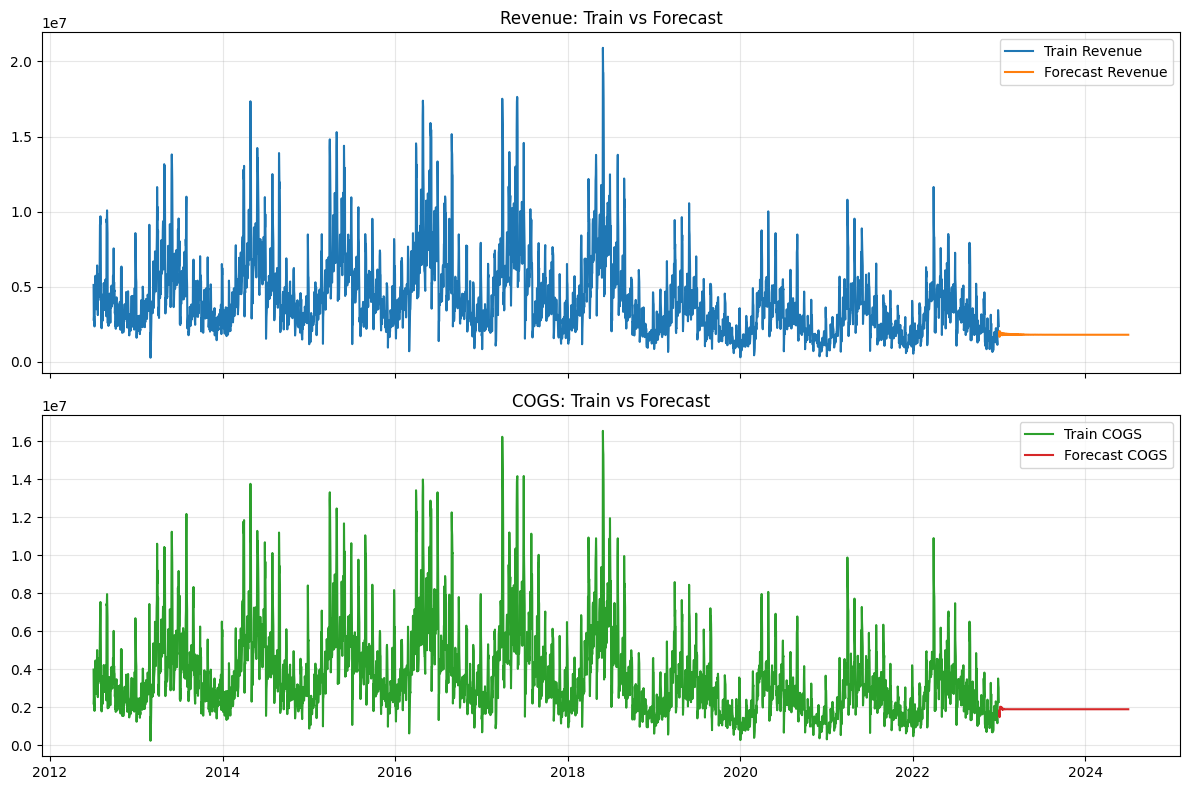

In [ ]:
plot_train = train_df.copy()
plot_train["Date"] = pd.to_datetime(plot_train["Date"], errors="coerce")
plot_train = plot_train.dropna(subset=["Date"]).sort_values("Date")

plot_fc = forecast_df.copy()
plot_fc["Date"] = pd.to_datetime(plot_fc["Date"], errors="coerce")
plot_fc = plot_fc.dropna(subset=["Date"]).sort_values("Date")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(plot_train["Date"], plot_train["Revenue"], label="Train Revenue", color="#1f77b4")
axes[0].plot(plot_fc["Date"], plot_fc["Revenue"], label="Forecast Revenue", color="#ff7f0e")
axes[0].set_title("Revenue: Train vs Forecast")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_train["Date"], plot_train["COGS"], label="Train COGS", color="#2ca02c")
axes[1].plot(plot_fc["Date"], plot_fc["COGS"], label="Forecast COGS", color="#d62728")
axes[1].set_title("COGS: Train vs Forecast")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()